<a href="https://colab.research.google.com/github/SagarLekhak/IMG_689_Graduate_Special_Topics/blob/main/gee_assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Sagar Lekhak**

**Rochester Institute of Technology.**

In [2]:
# Install required libraries
!pip install folium rasterio geopandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 19.3 MB/s eta 0:00:00


In [3]:
!pip install earthengine-api

In [5]:
!earthengine authenticate

E0000 00:00:1743477530.567443    1071 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1743477530.578434    1071 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
Authenticate: Limited support in Colab. Use ee.Authenticate() or --auth_mode=notebook instead.
W0401 03:18:55.348972 133043489689600 _default.py:711] No project ID could be determined. Consider running `gcloud config set project` or setting the GOOGLE_CLOUD_PROJECT environment variable
To authorize access needed by Earth Engine, open the following URL in a web browser and follow the instructions. If the web browser does not start automatically, please manually browse the URL below.

    https://code.earthengine.google.com/client-auth?scopes=https%3A//www.googleapis.com/auth/earthengine%20https%3A//www.googleapis.com/auth/cloud-platform%20h

In [6]:
import ee
ee.Initialize(project='ee-sl3088')  # actual project ID in GEE
# ee.Initialize()

In [7]:
import geemap
import folium
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
#####

# Define Tsho Rolpa Lake coordinates (longitude, latitude for GEE)  (taken from middle of the lake .)
# lat = 27.860539
# long = 86.477390

# # Define Tilicho Lake coordinates (longitude, latitude for GEE)  (taken from middle of the lake .)
# long = 83.857268
# lat = 28.682617

# # Define Rara Lake coordinates (longitude, latitude for GEE)  (taken from middle of the lake .)
long = 82.090886
lat = 29.531910

lake_point = ee.Geometry.Point([long, lat])

# Buffer the point by 200m to create a circular ROI
roi_200m = lake_point.buffer(200)  # 200m radius

# Extract bounding box of the buffered ROI (as a polygon)
roi_bbox = roi_200m.bounds()

# Print the geometries (for verification)
print("200m Buffered ROI (Circle):", roi_200m.getInfo())
print("Bounding Box ROI (Polygon):", roi_bbox.getInfo())

# Visualize on a map
center = [lat, long]  # Lat, Lon for folium
m = folium.Map(location=center, zoom_start=14)

# Add the geometries to the map
folium.GeoJson(
    data=roi_200m.getInfo(),
    name="200m Buffer",
    style_function=lambda x: {"color": "blue", "fillOpacity": 0.1}
).add_to(m)

folium.GeoJson(
    data=roi_bbox.getInfo(),
    name="Bounding Box",
    style_function=lambda x: {"color": "red", "fillOpacity": 0}
).add_to(m)

# Add a marker for the lake center
folium.Marker(
    location=center,
    popup="Rara Lake Center",
    icon=folium.Icon(color="green")
).add_to(m)

# Add layer control and show map
folium.LayerControl().add_to(m)
print("Verify the ROI (blue circle) and bounding box (red rectangle):")


200m Buffered ROI (Circle): {'type': 'Polygon', 'coordinates': [[[82.090886, 29.533709773190303], [82.09030822720848, 29.53363814096797], [82.08977644742626, 29.533428946516313], [82.08933299190282, 29.533098842494393], [82.08901316006767, 29.532674106209644], [82.08884240958031, 29.53218854762364], [82.0888343301986, 29.531680817781595], [82.08898956265217, 29.5311913320077], [82.08929574838601, 29.530759052836324], [82.08972851394152, 29.530418388760708], [82.09025341141913, 29.53019645560675], [82.09082866045644, 29.530110918436076], [82.09140847348434, 29.53016858566221], [82.091946699714, 29.53036486720856], [82.09240049801325, 29.53068413980535], [82.09273374653777, 29.531100990370536], [82.09291991787377, 29.531582238573964], [82.0929441908794, 29.53208957768735], [82.09280463104164, 29.53258262360373], [82.09251234520681, 29.533022129385326], [82.09209059813618, 29.53337310947045], [82.09157296100277, 29.533607624805512], [82.0910006390929, 29.533707007117943], [82.090886, 29.5

In [9]:
# Define coordinates for the Lake
lake_lon, lake_lat = long, lat

roi_buffer = roi_200m  # Use the buffered ROI

roi_polygon = roi_bbox  # Use the bounding box ROI


In [10]:
 # functions to process and extract temperature data from landsat and apply mask.
def process_landsat(collection_name, st_band, scale, offset, qa_band, cloud_bits):
    collection = ee.ImageCollection(collection_name) \
        .filterBounds(roi_polygon) \
        .filterDate('1982-01-01', '2025-01-01')

    #The bitwiseAnd(cloud_bits) operation below isolates specific bit flags that indicate clouds, cloud shadows, cirrus clouds, and snow.
    # gt(0) ensures that only pixels where these bits are set (cloud/snow) are marked as True (to be masked).
    def mask_clouds(image):
        qa = image.select(qa_band)
        cloud_mask = qa.bitwiseAnd(cloud_bits).gt(0)  # Mask clouds and snow. More details in the following cell.  #note: It can also be done as in next cell .
        return image.updateMask(cloud_mask.Not()) # cloud_mask.Not() inverts the mask, keeping only pixels without clouds or snow.
                                                  # updateMask() applies the mask, setting cloud-covered pixels to null (invisible).

    def extract_temp(image):
        masked_img = mask_clouds(image)
        temp = masked_img.select(st_band).multiply(scale).add(offset)  # Convert to Kelvin
        mean_temp = temp.reduceRegion(
            reducer=ee.Reducer.mean(), geometry=roi_polygon, scale=30
        ).get(st_band)
        return ee.Feature(None, {'timestamp': image.date().format(), 'temperature': mean_temp})

    return collection.map(extract_temp).getInfo()


In [13]:
# Alternative way of applying mask.

# def process_landsat(collection_name, st_band, scale, offset, qa_band, cloud_bits):
#     collection = ee.ImageCollection(collection_name) \
#         .filterBounds(roi_polygon) \
#         .filterDate('1982-01-01', '2025-01-01')

#     def mask_clouds(image):
#         qa = image.select(qa_band)

#         # Mask cirrus (bit 1), cloud (bit 3), shadow (bit 4), snow (bit 5)
#         cirrus_mask = qa.bitwiseAnd(1 << 1).gt(0)
#         cloud_mask = qa.bitwiseAnd(1 << 3).gt(0)
#         shadow_mask = qa.bitwiseAnd(1 << 4).gt(0)
#         snow_mask = qa.bitwiseAnd(1 << 5).gt(0)

#         # Cloud confidence (bit 6-7 for medium/high confidence)
#         cloud_conf_mask = qa.bitwiseAnd((1 << 6) | (1 << 7)).gt(0)

#         # Combine all masks
#         total_mask = cirrus_mask.Or(cloud_mask).Or(shadow_mask).Or(snow_mask).Or(cloud_conf_mask)

#         return image.updateMask(total_mask.Not())  # Keep only clear pixels

#     def extract_temp(image):
#         masked_img = mask_clouds(image)
#         temp = masked_img.select(st_band).multiply(scale).add(offset)  # Convert to Kelvin
#         mean_temp = temp.reduceRegion(
#             reducer=ee.Reducer.mean(), geometry=roi_polygon, scale=30
#         ).get(st_band)
#         return ee.Feature(None, {'timestamp': image.date().format(), 'temperature': mean_temp})

#     return collection.map(extract_temp).getInfo()


No valid data for Landsat_4
Saved Landsat_5_temperature_timeseries.csv
Saved Landsat_7_temperature_timeseries.csv
Saved Landsat_8_temperature_timeseries.csv
Saved Landsat_9_temperature_timeseries.csv


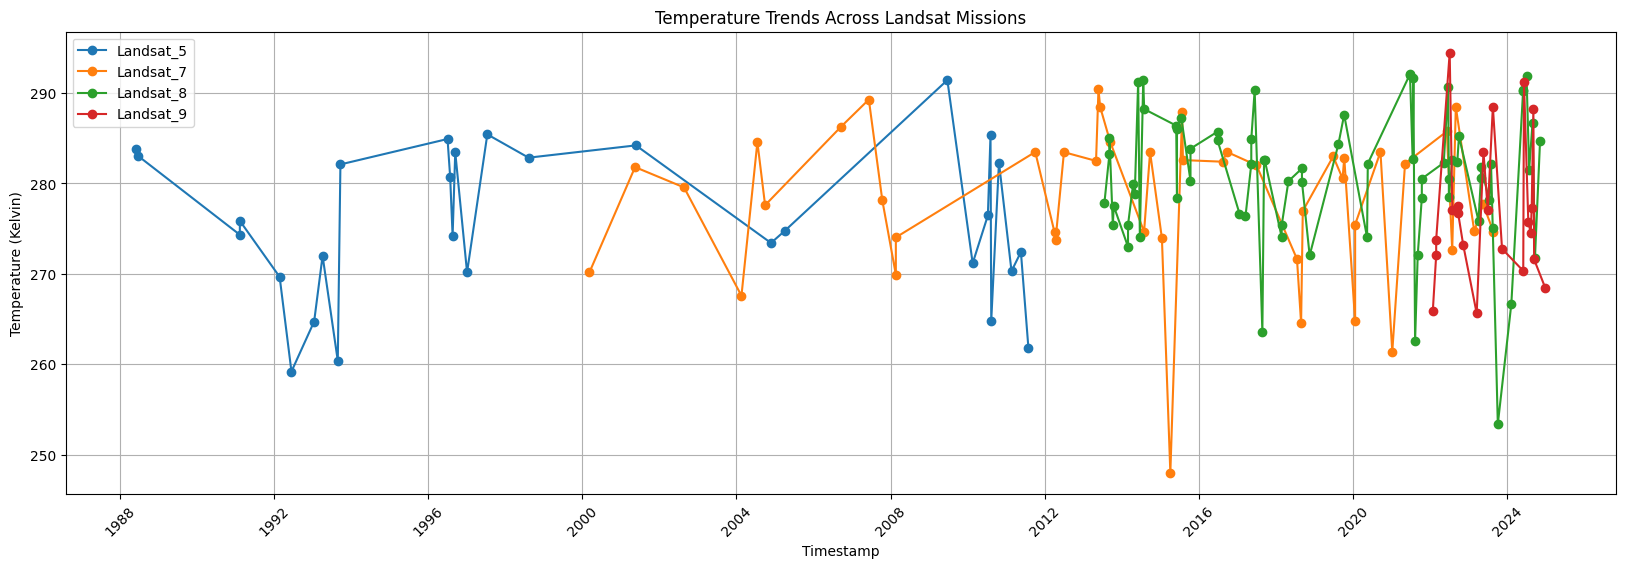

In [11]:
#Extract timestamps and temperature from five landsats and plot their extracted results.

# Landsat details
# why use cloud bit 352 in the following code?. :
# Since QA_PIXEL is 16 bit and we are creating a mask based on bit positions. For this, use following info.
# 3 - cloud, 5 - snow. 2 - cirrus (under these which bit to choose? look into the following resource.)
# References (Page 19): https://d9-wret.s3.us-west-2.amazonaws.com/assets/palladium/production/s3fs-public/media/files/LSDS-1619_Landsat8-9-Collection2-Level2-Science-Product-Guide-v6.pdf

# Following info is provided in https://developers.google.com/earth-engine/datasets/catalog/landsat

landsat_params = [
    ["LANDSAT/LT04/C02/T1_L2", "ST_B6", 0.00341802, 149.0, "QA_PIXEL", 352, "Landsat_4"],  # 3 - cloud, 5 - snow. 2 - cirrus
    ["LANDSAT/LT05/C02/T1_L2", "ST_B6", 0.00341802, 149.0, "QA_PIXEL", 352, "Landsat_5"],
    ["LANDSAT/LE07/C02/T1_L2", "ST_B6", 0.00341802, 149.0, "QA_PIXEL", 352, "Landsat_7"],
    ["LANDSAT/LC08/C02/T1_L2", "ST_B10", 0.00341802, 149.0, "QA_PIXEL", 352, "Landsat_8"],
    ["LANDSAT/LC09/C02/T1_L2", "ST_B10", 0.00341802, 149.0, "QA_PIXEL", 352, "Landsat_9"],
]

# Dictionary to store data separately
landsat_data = {}

for params in landsat_params:
    collection, st_band, scale, offset, qa_band, cloud_bits, landsat_name = params
    data = process_landsat(collection, st_band, scale, offset, qa_band, cloud_bits)

    # Extract only the 'properties' field
    extracted_data = [feature['properties'] for feature in data['features']]

    if extracted_data:
        df = pd.DataFrame(extracted_data)
        if 'timestamp' in df.columns:
            df['timestamp'] = pd.to_datetime(df['timestamp'])
            df = df.dropna(subset=['temperature'])  # Remove missing temperature values

            # Sort by timestamp
            df = df.sort_values(by='timestamp')

            # Store DataFrame in dictionary
            landsat_data[landsat_name] = df

            # Save CSV separately
            filename = f"{landsat_name}_temperature_timeseries.csv"
            df.to_csv(filename, index=False)
            print(f"Saved {filename}")
        else:
            print(f"Error: 'timestamp' column missing in {landsat_name}")
    else:
        print(f"No valid data for {landsat_name}")

# Plot comparison
plt.figure(figsize=(20, 6))

for landsat, df in landsat_data.items():
    plt.plot(df['timestamp'], df['temperature'], marker='o', linestyle='-', label=landsat)

plt.xlabel('Timestamp')
plt.ylabel('Temperature (Kelvin)')
plt.title('Temperature Trends Across Landsat Missions')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend()
plt.show()


Saved combined data to combined_landsat_temperatures.csv


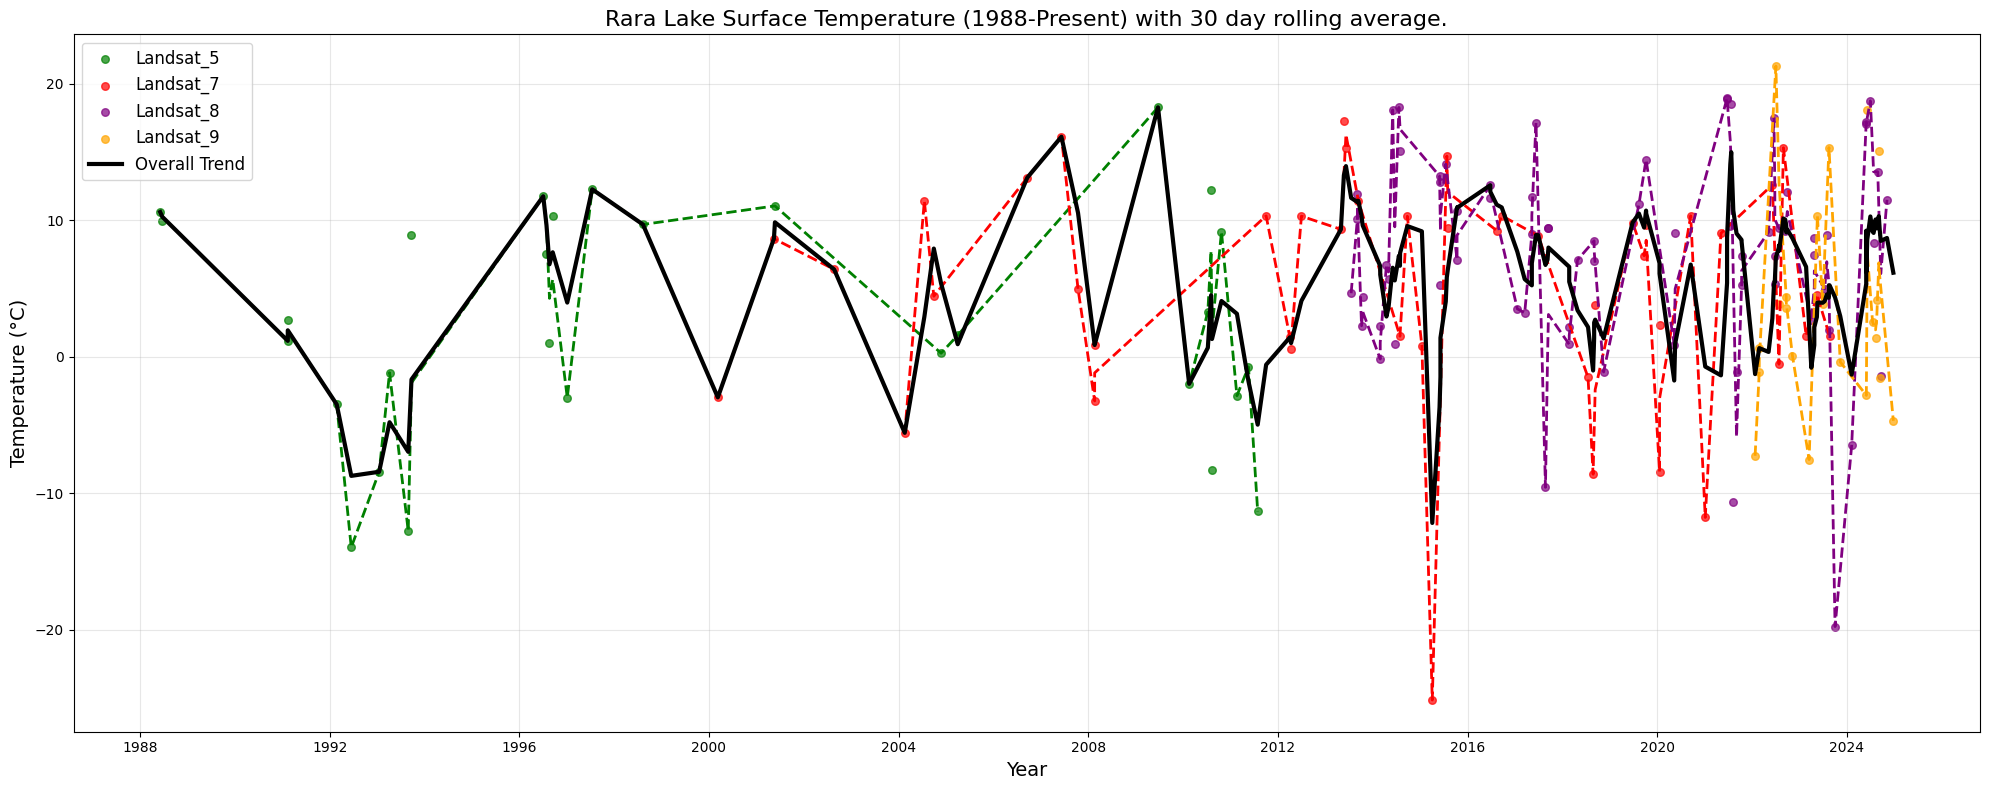

In [22]:
# Additional code to combine and visualize all the landsats data together.

# 1. Combine all saved CSV files into one DataFrame
import glob

# Get all the CSV files
csv_files = glob.glob("*_temperature_timeseries.csv")

# Read and combine them
all_data = []
for file in csv_files:
    df = pd.read_csv(file)
    df['mission'] = file.replace("_temperature_timeseries.csv", "")
    all_data.append(df)

combined_df = pd.concat(all_data, ignore_index=True)

# 2. Clean the combined data
# Convert timestamp to datetime
combined_df['timestamp'] = pd.to_datetime(combined_df['timestamp'])

# Remove duplicates (same timestamp and mission)   # keeps the first occurence and removes subsequent duplicates.
combined_df = combined_df.drop_duplicates(subset=['timestamp', 'mission'])

# Sort by date
combined_df = combined_df.sort_values('timestamp')

# 3. Save combined data to single CSV
combined_df.to_csv('combined_landsat_temperatures.csv', index=False)
print("Saved combined data to combined_landsat_temperatures.csv")

# 4. Visualize the complete time series
plt.figure(figsize=(20, 8))

# Convert Kelvin to Celsius for visualization
combined_df['temperature_c'] = combined_df['temperature'] - 273.15

# Create a color map for different missions
color_map = {
    'Landsat_4': 'blue',
    'Landsat_5': 'green',
    'Landsat_7': 'red',
    'Landsat_8': 'purple',
    'Landsat_9': 'orange'
}

# Plot each mission with different colors
for mission, color in color_map.items():
    mission_data = combined_df[combined_df['mission'] == mission]
    if not mission_data.empty:
        plt.scatter(mission_data['timestamp'], mission_data['temperature_c'],
                   color=color, s=30, label=mission, alpha=0.7)

        # Add a smoothed trend line (30-day rolling average)
        mission_data = mission_data.set_index('timestamp')
        mission_data['smooth_temp'] = mission_data['temperature_c'].rolling('30D').mean()
        plt.plot(mission_data.index, mission_data['smooth_temp'],
                color=color, linewidth=2, linestyle='--')

plt.title('Rara Lake Surface Temperature (1988-Present) with 30 day rolling average.', fontsize=16)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Add a general trend line (all missions combined)
all_data = combined_df.set_index('timestamp')
all_data['smooth_all'] = all_data['temperature_c'].rolling('180D').mean()
plt.plot(all_data.index, all_data['smooth_all'],
        color='black', linewidth=3, label='Overall Trend')

plt.legend(fontsize=12)
plt.tight_layout()
plt.show()

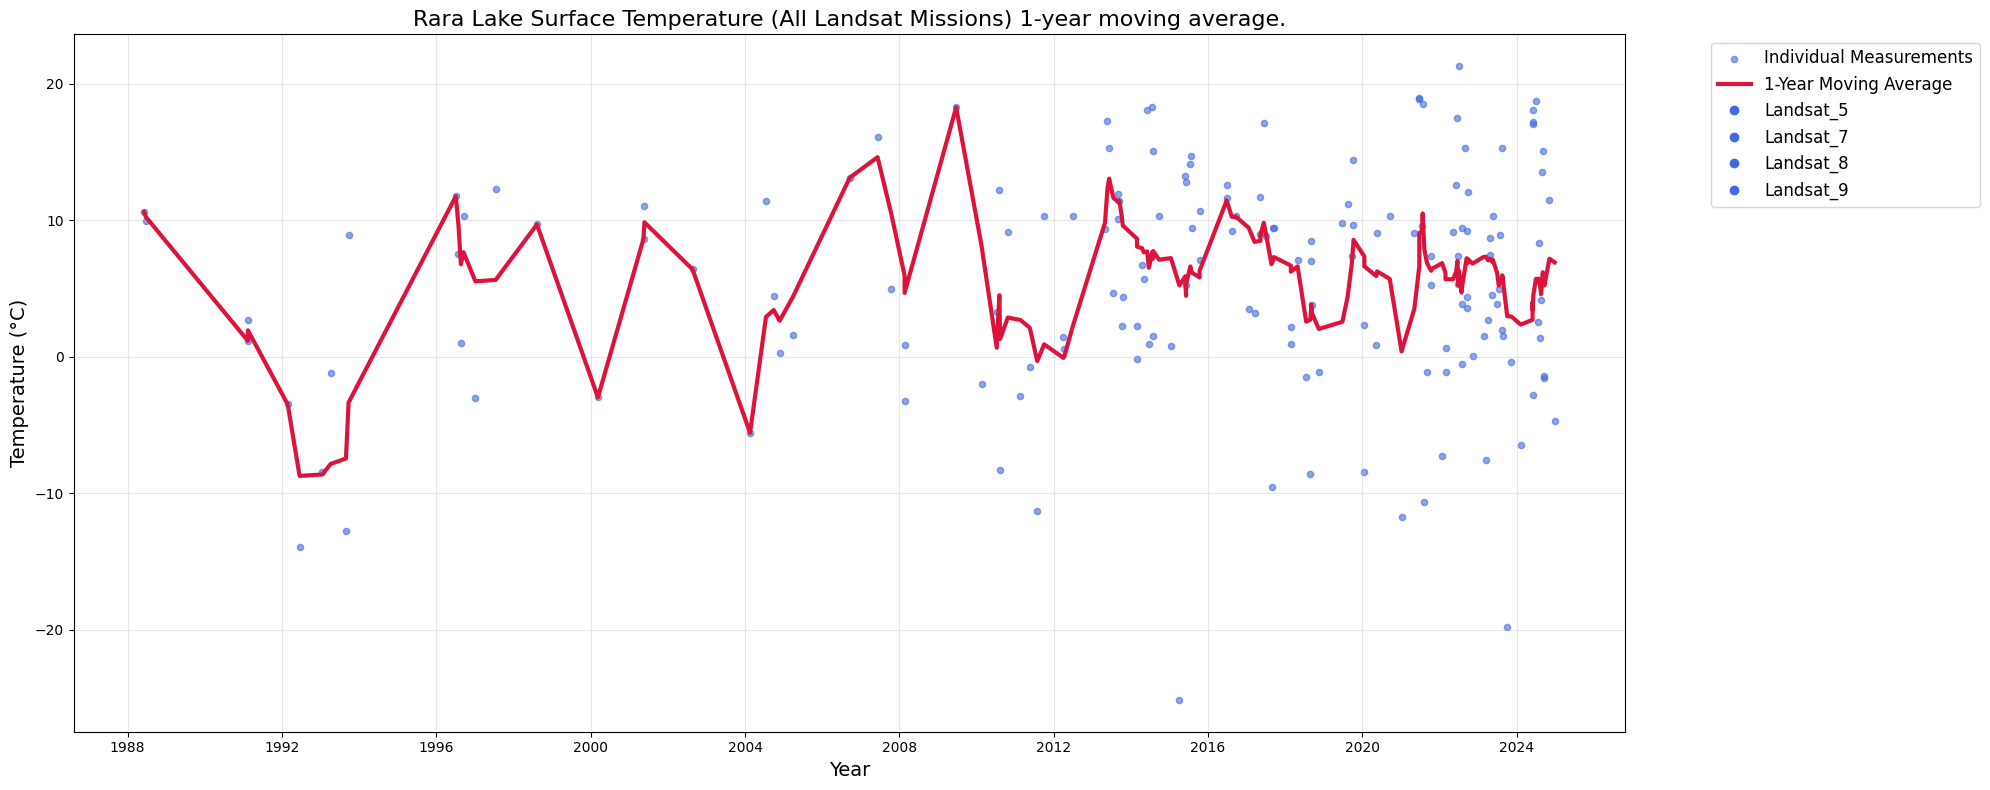

Saved combined data to rara_lake_combined_temperature.csv


In [23]:
# Same plot with 1 year moving average.
# Create the combined visualization
plt.figure(figsize=(20, 8))

# Plot all points with the same color
plt.scatter(combined_df['timestamp'], combined_df['temperature_c'],
            color='royalblue', s=20, alpha=0.6, label='Individual Measurements')

# Add a smoothed trend line (1-year rolling average)
combined_df = combined_df.set_index('timestamp')
combined_df['smooth_temp'] = combined_df['temperature_c'].rolling('365D').mean()

plt.plot(combined_df.index, combined_df['smooth_temp'],
         color='crimson', linewidth=3, label='1-Year Moving Average')

# Format the plot
plt.title('Rara Lake Surface Temperature (All Landsat Missions) 1-year moving average.', fontsize=16)
plt.ylabel('Temperature (°C)', fontsize=14)
plt.xlabel('Year', fontsize=14)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=12)

# Add mission markers for legend
for mission in landsat_data.keys():
    plt.plot([], [], 'o', color='royalblue', label=mission)  # Dummy points for legend

plt.legend(fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Save the combined data
combined_df.reset_index().to_csv('rara_lake_combined_temperature.csv', index=False)
print("Saved combined data to rara_lake_combined_temperature.csv")

Another Try